# 20 · HID-search-v3a: refining four ranked boundary seeds instead of one

**Question.** HID-search-v2's boundary stage B refines only the single best coarse cut
per round. Does refining the **four** best distinct coarse partitions (level by level,
seed by seed, same caps) shorten the complete archive of the full method on six declared
boundary cells?

**Design.** Two full-method arms rerun L, P, C, D, G and B independently on every string:
`hid_full` (k = 1, the accepted search-v2 method, byte for byte) and `hid_refine4`
(k = 4). Fresh strings from four reserved namespaces were generated only after a
validated freeze. The primary contrast is the paired, equal-cell mean of
(bits(hid_full) − bits(hid_refine4)) / n over 120 units in six cells, with one
10,000-draw 99% percentile interval. Everything else is descriptive.

This notebook reads saved artifacts only. Run the first cell first.

In [1]:
# --- Run me first: make this notebook executable from anywhere -----------------
import os, sys

def _find_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, "PROTOCOL_order_discovery.md")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    for cand in [os.path.expanduser("~/Documents/projects/CausalBool/index-deconvolution")]:
        if os.path.isfile(os.path.join(cand, "PROTOCOL_order_discovery.md")):
            return cand
    raise RuntimeError("Could not locate the index-deconvolution root. "
                       "Set ROOT = '/path/to/index-deconvolution' by hand and re-run.")

ROOT = _find_root()
for _sub in ["src", "level2", "level3", "level4", "level5", "level6", "level7", "level8"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)

DATA       = os.path.join(ROOT, "finance", "data")          # 23 tickers, 3 years
DATA_LONG  = os.path.join(ROOT, "finance", "data_long")     # 12 instruments, ~30+ years
BIO        = os.path.join(os.path.dirname(ROOT), "data", "bio", "raw")  # .bnet networks

import matplotlib.pyplot as plt
import numpy as np

# a clean, consistent didactic style
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "bold", "image.cmap": "magma",
})
INK, HL, OK, BAD = "#20222b", "#c1121f", "#2a9d8f", "#e07a1f"
print("repo root :", ROOT)
print("ready. matplotlib + numpy loaded; code layers on the path.")

repo root : /Users/alberto/Documents/projects/CausalBool/index-deconvolution
ready. matplotlib + numpy loaded; code layers on the path.


In [2]:
from pathlib import Path
_cands = [Path.cwd(), Path.cwd() / "index-deconvolution", Path(ROOT)]
ID_ROOT = next(p.resolve() for p in _cands
               if (p / "PROTOCOL_order_discovery.md").is_file()
               and (p / "results" / "hierarchy_search_v3a" / "search-confirm-v3a-r1").is_dir())
ROOT = str(ID_ROOT)
for _p in (os.path.join(os.path.dirname(ROOT), "src"), ROOT):
    while _p in sys.path:
        sys.path.remove(_p)
    sys.path.insert(0, _p)
sys.modules.pop("hierarchy", None)          # a sibling repo ships a module "hierarchy"
import json, hashlib, csv, collections
import numpy as np
import matplotlib.pyplot as plt
from hierarchy.decode import decode_archive                 # saved archives only

RUN = ID_ROOT / "results" / "hierarchy_search_v3a" / "search-confirm-v3a-r1"
DEV = ID_ROOT / "results" / "hierarchy_search_v3a" / "development"
def load(p):
    return json.loads(Path(p).read_text())
summary, decision = load(RUN / "summary.json"), load(RUN / "DECISION.json")
verification, audit = load(RUN / "verification.json"), load(RUN / "arithmetic_audit.json")
freeze_sha = (RUN / "freeze.sha256").read_text().strip()
with open(RUN / "tables" / "per_string.csv") as fh:
    strings = list(csv.DictReader(fh))
compat, devsum = load(DEV / "compatibility.json"), load(DEV / "development_summary.json")
gate = load(DEV / "engineering_gate.json")
def sha(b):
    return hashlib.sha256(b).hexdigest()
def num(x):
    return None if x in ("", "None", None) else float(x)
print("freeze:", freeze_sha[:16], "| verdict:", decision["verdict"],
      "| verification:", verification["engineering_status"], verification["completeness"])

freeze: 05dd799d154e5e53 | verdict: HARMFUL | verification: valid complete


## 1. Development: the k = 1 path is the accepted method, byte for byte

Before any fresh string existed, `hid_full` was re-run on every retained search-v2
string and compared with the accepted archive and telemetry; `hid_refine4` was run on the
fixed development strings. Neither result was a gate on efficacy.

In [3]:
print("compatibility population:", compat["population"], "| byte-identical archives:",
      compat["archives_byte_identical"], "| field differences:", compat["difference_count"],
      "| statuses:", compat["statuses"])
print("hid_full configuration hash unchanged:", compat["config_sha256_now"] == compat["config_sha256_frozen_v2"])
print("engineering gate:", gate["pass"], "| treatment terminal records:",
      gate["treatment_terminal_records"], "/", gate["treatment_population"],
      "| paired target traces complete:", gate["paired_target_traces_complete"], "/", gate["paired_target_strings"])
t = devsum["targets"]
print("development targets (inspected, descriptive): string signs", t["string_signs"],
      "| equal-cell mean saving:", t["equal_cell_mean_saving"])
for arm in ("full", "refine4"):
    cov = t[f"{arm}_coverage"]
    print(f"  {arm:8s} supplied cuts within 8 bits:",
          {k: f'{v["pooled_numerator"]}/{v["pooled_denominator"]}' for k, v in cov.items()})

compatibility population: 1792 | byte-identical archives: 1792 | field differences: 0 | statuses: {'ok': 1792}
hid_full configuration hash unchanged: True
engineering gate: True | treatment terminal records: 208 / 208 | paired target traces complete: 176 / 176
development targets (inspected, descriptive): string signs {'better': 28, 'tie': 104, 'worse': 44} | equal-cell mean saving: -0.005369688185455944
  full     supplied cuts within 8 bits: {'proposed': '720/880', 'evaluated': '720/880', 'returned': '287/880'}
  refine4  supplied cuts within 8 bits: {'proposed': '720/880', 'evaluated': '720/880', 'returned': '259/880'}


## 2. The primary contrast

Positive values mean k = 4 saved bits. The interval is the shared stratified bootstrap
(seed and draws are printed from the decision record).

In [4]:
p = summary["primary"]
print("verdict:", decision["verdict"], "| estimate (bits per input bit):", decision["estimate_bits_per_input_bit"],
      "| 99% interval:", decision["ci99"])
print("units:", p["available_units"], "of", p["required_units"], "| bootstrap:",
      {k: decision["bootstrap"][k] for k in ("draws", "seed", "level")} if decision["bootstrap"] else None)
print("audit: point recomputed equal:", audit.get("decision_point_equal"),
      "| interval recomputed equal:", audit.get("decision_ci_equal"),
      "| cell means equal:", audit.get("cell_means_equal"), "| archive problems:", audit["problem_count"])
for c in summary["cells"]:
    print(f'{c["cell"]:28s} units {c["available_units"]:>2}  mean {c["mean_unit_saving"]!s:>24}  '
          f'strings better/tie/worse {c["strings_better"]}/{c["strings_tie"]}/{c["strings_worse"]}')

verdict: HARMFUL | estimate (bits per input bit): -0.0063290600504822 | 99% interval: [-0.00833260223670385, -0.004177554260442437]
units: 120 of 120 | bootstrap: {'draws': 10000, 'seed': 55001, 'level': 0.99}
audit: point recomputed equal: True | interval recomputed equal: True | cell means equal: True | archive problems: 0
boundary|F12|4096            units 20  mean    -0.013471845267138327  strings better/tie/worse 0/14/26
boundary_large|F12|16384     units 20  mean     -0.02968636473938946  strings better/tie/worse 0/15/25
boundary_large|F12|65536     units 20  mean                      0.0  strings better/tie/worse 0/40/0
boundary_large|F12|131072    units 20  mean                      0.0  strings better/tie/worse 0/40/0
boundary_stress|S02|4096     units 20  mean     0.006880584441327153  strings better/tie/worse 18/17/5
boundary_stress|S02|65536    units 20  mean    -0.001696734737692562  strings better/tie/worse 0/25/15
controls|F01|4096            units  2  mean              

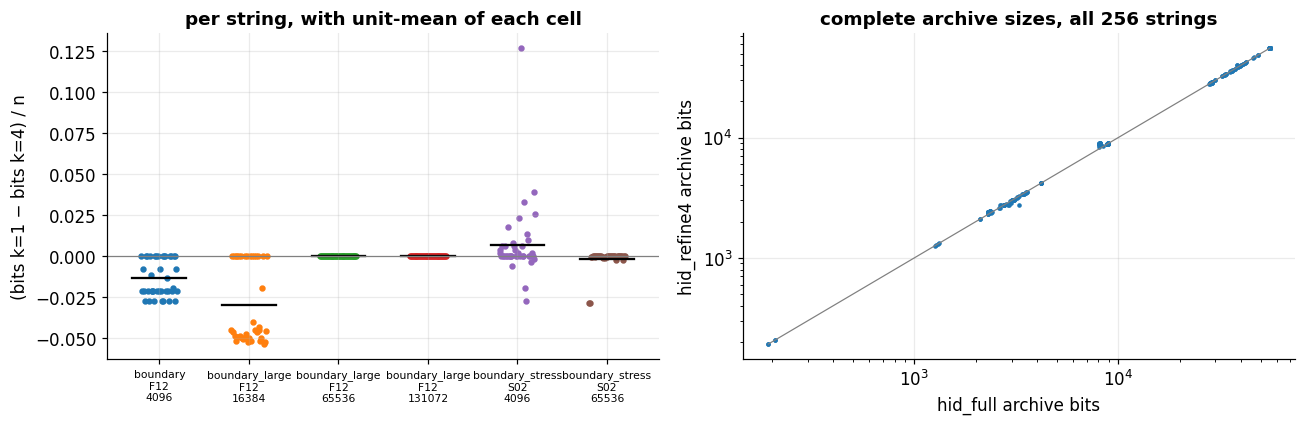

In [5]:
prim = [c for c in summary["cells"] if not c["cell"].startswith("controls|")]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i, c in enumerate(prim):
    xs = [num(s["saving_per_input_bit"]) for s in strings
          if f'{s["role"]}|{s["family"]}|{s["base_length"]}' == c["cell"]]
    xs = [x for x in xs if x is not None]
    ax[0].scatter(np.full(len(xs), i) + np.linspace(-0.2, 0.2, len(xs)), xs, s=10)
    ax[0].plot([i - 0.3, i + 0.3], [c["mean_unit_saving"]] * 2, color="k")
ax[0].axhline(0, color="grey", lw=0.8)
ax[0].set_xticks(range(len(prim)), [c["cell"].replace("|", "\n") for c in prim], fontsize=7)
ax[0].set_ylabel("(bits k=1 − bits k=4) / n"); ax[0].set_title("per string, with unit-mean of each cell")
a = [num(s["hid_full_bits"]) for s in strings]; b = [num(s["hid_refine4_bits"]) for s in strings]
ok = [(x, y) for x, y in zip(a, b) if x is not None and y is not None]
ax[1].loglog([x for x, _ in ok], [y for _, y in ok], ".", ms=4)
lim = [min(min(ok)), max(max(ok))]
ax[1].plot(lim, lim, color="grey", lw=0.8)
ax[1].set_xlabel("hid_full archive bits"); ax[1].set_ylabel("hid_refine4 archive bits")
ax[1].set_title("complete archive sizes, all 256 strings")
plt.tight_layout(); plt.show()

## 3. Re-check: archives decode to the input they claim

One string per primary cell: both HID archives are read from disk, hashed and decoded
with the independent decoder; the decoded bits must hash to the corpus manifest entry.

In [6]:
man = {}
for p_ in sorted(RUN.glob("corpus_manifest.*.jsonl")):
    for line in p_.read_text().splitlines():
        m = json.loads(line)
        man[m["case_ids"][0]], man[m["case_ids"][1]] = m["base_sha256"], m["full_sha256"]
seen = set()
for s in strings:
    cell = f'{s["role"]}|{s["family"]}|{s["base_length"]}'
    if cell in seen:
        continue
    seen.add(cell)
    rows = {r["method"]: r for r in load(RUN / "rows" / f'{s["case_id"]}.json')}
    for m in ("hid_full", "hid_refine4"):
        data = (RUN / rows[m]["archive_path"]).read_bytes()
        ok = sha(data) == rows[m]["archive_sha256"] and sha(decode_archive(data).encode()) == man[s["case_id"]]
        print(f'{s["case_id"]:36s} {m:12s} {8 * len(data):>8} bits  decodes to input: {ok}')

boundary-F12-4096-6000-base          hid_full         2384 bits  decodes to input: True
boundary-F12-4096-6000-base          hid_refine4      2384 bits  decodes to input: True
boundary_large-F12-16384-7000-base   hid_full         8056 bits  decodes to input: True
boundary_large-F12-16384-7000-base   hid_refine4      8792 bits  decodes to input: True
boundary_large-F12-65536-7000-base   hid_full        28656 bits  decodes to input: True
boundary_large-F12-65536-7000-base   hid_refine4     28656 bits  decodes to input: True
boundary_large-F12-131072-7000-base  hid_full        55328 bits  decodes to input: True
boundary_large-F12-131072-7000-base  hid_refine4     55328 bits  decodes to input: True
boundary_stress-S02-4096-8000-base   hid_full         3016 bits  decodes to input: True
boundary_stress-S02-4096-8000-base   hid_refine4      3000 bits  decodes to input: True
boundary_stress-S02-65536-8000-base  hid_full        38376 bits  decodes to input: True
boundary_stress-S02-65536-8000-b

## 4. What the search did: statuses, stages, caps and traces

Wall and RSS are instrumented measurements (both arms ran with the trace observer).
A cap exit is a normal outcome of the deterministic search; a `timeout_raw` row is a
worker killed by the watchdog whose cost is the validated raw archive.

In [7]:
for m, v in summary["hid_telemetry"].items():
    print(m, "| selected stage:", v["selected_stage"], "| B stop:", v["B_stop_reason"], "| B cap exits:", v["B_cap_exits"])
for m, v in summary["resources"].items():
    print(f'{m:13s} jobs {v["jobs"]:>4}  statuses {v["statuses"]}  max wall {v["max_worker_wall_s"]:.2f} s  '
          f'max RSS {v["max_peak_rss_bytes"] / 2**20:.0f} MiB')
for m, v in summary["trace"].items():
    print(m, "| trace status:", v["trace_status"], "| totals:",
          {k: x["total"] for k, x in v.items() if k != "trace_status"})
print("censored baseline rows:", summary["censored_baselines"],
      "| portfolio conclusion blocked by censoring:", summary["portfolio_conclusion_blocked_by_censoring"])
print("versus portfolio (descriptive):", {m: v["equal_cell_mean"] for m, v in summary["versus_portfolio"].items()})
print("control cells:", [(c["cell"], c["strings_better"], c["strings_tie"], c["strings_worse"]) for c in summary["controls"]])

hid_full | selected stage: {'B': 133, 'G': 4, 'L': 111, 'raw': 8} | B stop: {'no_strict_improvement': 248, 'root_trial_cap': 8} | B cap exits: {'root_trial_cap': 8}
hid_refine4 | selected stage: {'B': 108, 'G': 4, 'L': 136, 'raw': 8} | B stop: {'leaf_length_charge_cap': 219, 'no_strict_improvement': 36, 'root_trial_cap': 1} | B cap exits: {'leaf_length_charge_cap': 219, 'root_trial_cap': 1}
bernoulli     jobs  256  statuses {'ok': 256}  max wall 2.59 s  max RSS 26 MiB
context       jobs  256  statuses {'ok': 256}  max wall 1.14 s  max RSS 26 MiB
gaps          jobs  256  statuses {'ok': 256}  max wall 0.10 s  max RSS 30 MiB
hid_full      jobs  256  statuses {'ok': 256}  max wall 10.87 s  max RSS 287 MiB
hid_refine4   jobs  256  statuses {'ok': 256}  max wall 11.20 s  max RSS 286 MiB
lzma          jobs  256  statuses {'ok': 256}  max wall 0.09 s  max RSS 41 MiB
pair_grammar  jobs  256  statuses {'ok': 256}  max wall 0.19 s  max RSS 63 MiB
period        jobs  256  statuses {'ok': 256}  ma

## What this result can and cannot say

* **One algorithm change, one fixed mixture.** The contrast compares k = 4 with k = 1 on
  six declared boundary cells. It is not evidence about other families, other sizes, or
  the nine-method portfolio, and controls may change in either direction.
* **Familiar generators, fresh instances.** F12 and S02 were already inspected in
  earlier phases; only the instances are new.
* **Search cost, not mechanism.** Proposed, evaluated and returned cuts describe what
  the search did; no prospective comparison with true cuts was made, and the trace does
  not identify why one arm wins.
* **A code length under one fixed language and resource policy**, not Kolmogorov
  complexity and not generator recovery. The accepted search-v2 conclusion is unchanged.